# **PhonePe Transaction Insights – EDA**

##### **Project Type** - EDA
##### **Domain** - Finance / Payment Systems
##### **Data Source** - PhonePe Pulse GitHub Repository

# **Project Summary**

This project performs an end-to-end Exploratory Data Analysis on the PhonePe Pulse dataset — India's largest open digital payments dataset. We extract JSON data from the PhonePe Pulse GitHub repository, load it into a MySQL database across 9 structured tables, and use Python to visualise transaction, user, and geographic trends. Key findings include the dominance of Peer-to-Peer payments, Maharashtra and Karnataka leading in transaction value, and Q4 consistently being the peak payment quarter across all years.

# **Problem Statement**

With the increasing reliance on digital payment systems like PhonePe, understanding the dynamics of transactions, user engagement, and geographic distribution is crucial. This project analyses aggregated payment categories, maps transaction values at state and district levels, and identifies top-performing regions to generate actionable business insights.

#### **Business Objective**

To analyse PhonePe's transaction and user data to:
1. Identify high-value states and districts for targeted expansion.
2. Understand payment category preferences to guide product strategy.
3. Discover low-engagement regions with high user counts (untapped opportunity).
4. Track growth trends to forecast demand.

# **General Guidelines**

1. Code is structured, commented, and reproducible end-to-end.
2. Every chart includes: choice justification, key insights, and business impact.
3. Visualisations follow the UBM rule (Univariate → Bivariate → Multivariate).
4. Minimum 20 meaningful charts are produced.

# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [63]:
# Core libraries
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import mysql.connector

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 14})
print('Libraries loaded ✅')

Libraries loaded ✅


### Dataset Loading

In [64]:
# ── Connect to MySQL and load key tables into DataFrames ──────────────────────
DB = dict(host='localhost', user='root', password='Yash@1904', database='phonepe_pulse')

conn = mysql.connector.connect(**DB)

agg_txn  = pd.read_sql('SELECT * FROM aggregated_transaction', conn)
agg_user = pd.read_sql('SELECT * FROM aggregated_user', conn)
map_txn  = pd.read_sql('SELECT * FROM map_transaction', conn)
map_user = pd.read_sql('SELECT * FROM map_user', conn)
top_txn  = pd.read_sql('SELECT * FROM top_transaction', conn)
top_user = pd.read_sql('SELECT * FROM top_user', conn)

conn.close()
print('Data loaded ✅')

Data loaded ✅


### Dataset First View

In [65]:
# First look at the aggregated transactions table
print('Shape:', agg_txn.shape)
agg_txn.head()

Shape: (5034, 7)


,id,state,year,quarter,transaction_type,transaction_count,transaction_amount
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,3,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,4,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,5,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [66]:
for name, df in [('agg_txn', agg_txn), ('agg_user', agg_user),
                 ('map_txn', map_txn), ('map_user', map_user),
                 ('top_txn', top_txn), ('top_user', top_user)]:
    print(f'{name:15s}  rows={df.shape[0]:7,}  cols={df.shape[1]}')

agg_txn          rows=  5,034  cols=7
agg_user         rows=  1,008  cols=6
map_txn          rows= 20,604  cols=7
map_user         rows= 20,608  cols=7
top_txn          rows= 18,295  cols=8
top_user         rows= 18,296  cols=7


### Dataset Information

In [67]:
agg_txn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5034 non-null   int64  
 1   state               5034 non-null   object 
 2   year                5034 non-null   int64  
 3   quarter             5034 non-null   int64  
 4   transaction_type    5034 non-null   object 
 5   transaction_count   5034 non-null   int64  
 6   transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 275.4+ KB


#### Duplicate Values

In [68]:
print('Duplicates in agg_txn:', agg_txn.duplicated().sum())
print('Duplicates in agg_user:', agg_user.duplicated().sum())

Duplicates in agg_txn: 0
Duplicates in agg_user: 0


#### Missing Values / Null Values

agg_txn: 0 null values
agg_user: 0 null values
map_txn: 0 null values


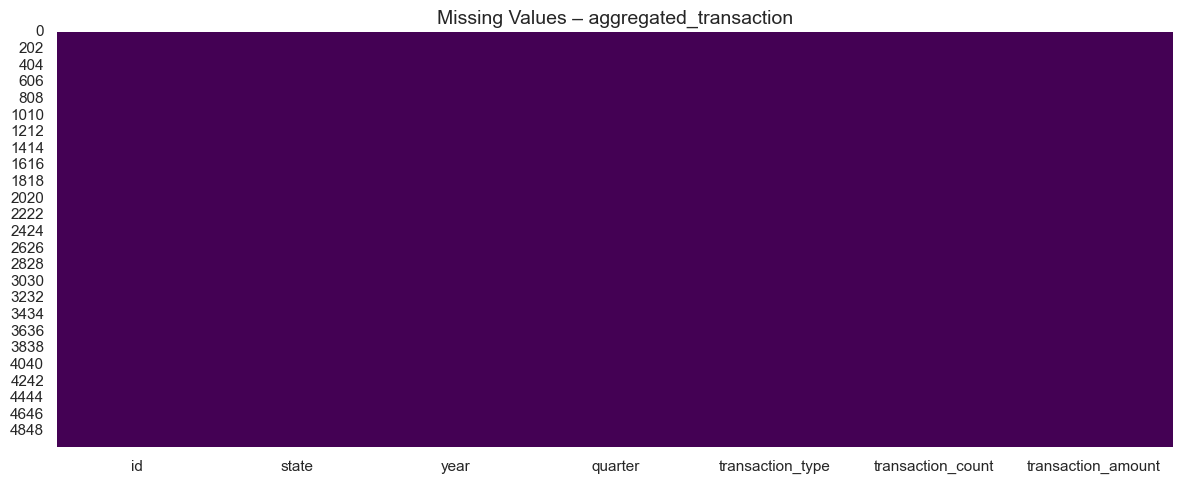

In [69]:
# Missing value summary across tables
for name, df in [('agg_txn', agg_txn), ('agg_user', agg_user), ('map_txn', map_txn)]:
    nulls = df.isnull().sum().sum()
    print(f'{name}: {nulls} null values')

# Visualise for agg_txn
sns.heatmap(agg_txn.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values – aggregated_transaction')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The aggregated_transaction table has **no missing values**. It covers **2018–2023** across **36 states/UTs** and **5 transaction types**. The data is quarterly. User tables similarly have no nulls. Map and Top tables are fully populated, giving us district and pincode-level granularity.

## ***2. Understanding Your Variables***

In [70]:
# Column names
print('agg_txn columns:', agg_txn.columns.tolist())
print('agg_user columns:', agg_user.columns.tolist())

agg_txn columns: ['id', 'state', 'year', 'quarter', 'transaction_type', 'transaction_count', 'transaction_amount']
agg_user columns: ['id', 'state', 'year', 'quarter', 'registered_users', 'app_opens']


In [71]:
# Descriptive statistics
agg_txn[['transaction_count', 'transaction_amount']].describe().round(2)

,transaction_count,transaction_amount
count,5.034000e+03,5.034000e+03
mean,4.673902e+07,6.863772e+10
std,1.690968e+08,2.685200e+11
min,2.000000e+00,3.440000e+01
25%,5.808950e+04,3.993888e+07
50%,5.158310e+05,4.394139e+08
75%,1.166629e+07,1.102822e+10
max,2.393918e+09,3.095666e+12


### Variables Description

| Column | Table | Description |
|--------|-------|-------------|
| state | all | Indian state/UT name |
| year | all | Year of record (2018–2023) |
| quarter | all | Quarter 1–4 |
| transaction_type | agg_txn | Payment category (P2P, Merchant, etc.) |
| transaction_count | txn tables | Number of transactions |
| transaction_amount | txn tables | Total INR value |
| registered_users | user tables | Cumulative registered users |
| app_opens | user tables | App open count |
| district | map tables | District name |
| entity_name | top tables | District or pincode identifier |

In [72]:
# Unique values per key column
print('States:', agg_txn['state'].nunique())
print('Years:', sorted(agg_txn['year'].unique()))
print('Transaction types:', agg_txn['transaction_type'].unique())

States: 36
Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Transaction types: ['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']


## 3. ***Data Wrangling***

In [73]:
# Create year-quarter period column for time-series
agg_txn['period'] = agg_txn['year'].astype(str) + '-Q' + agg_txn['quarter'].astype(str)
agg_user['period'] = agg_user['year'].astype(str) + '-Q' + agg_user['quarter'].astype(str)

# Convert amount to crores for readability
agg_txn['amount_cr'] = agg_txn['transaction_amount'] / 1e7
map_txn['amount_cr']  = map_txn['transaction_amount'] / 1e7

# Aggregate by period
period_txn = (agg_txn.groupby('period')
               .agg(txn_count=('transaction_count','sum'),
                    amount_cr=('amount_cr','sum'))
               .reset_index())

print('Wrangling complete ✅')
agg_txn.head(2)

Wrangling complete ✅


,id,state,year,quarter,transaction_type,transaction_count,transaction_amount,period,amount_cr
0,1,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06,2018-Q1,0.184531
1,2,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07,2018-Q1,1.213866


### Manipulations done:
- Added `period` column (e.g. `2021-Q3`) for chronological plotting.
- Converted `transaction_amount` to **crores** for human-readable axis labels.
- Aggregated tables by period, state, and transaction type for chart-ready DataFrames.

## ***4. Data Visualization, Storytelling & Experimenting with Charts***

#### Chart - 1 | Transaction Volume Over Time (Line Chart)

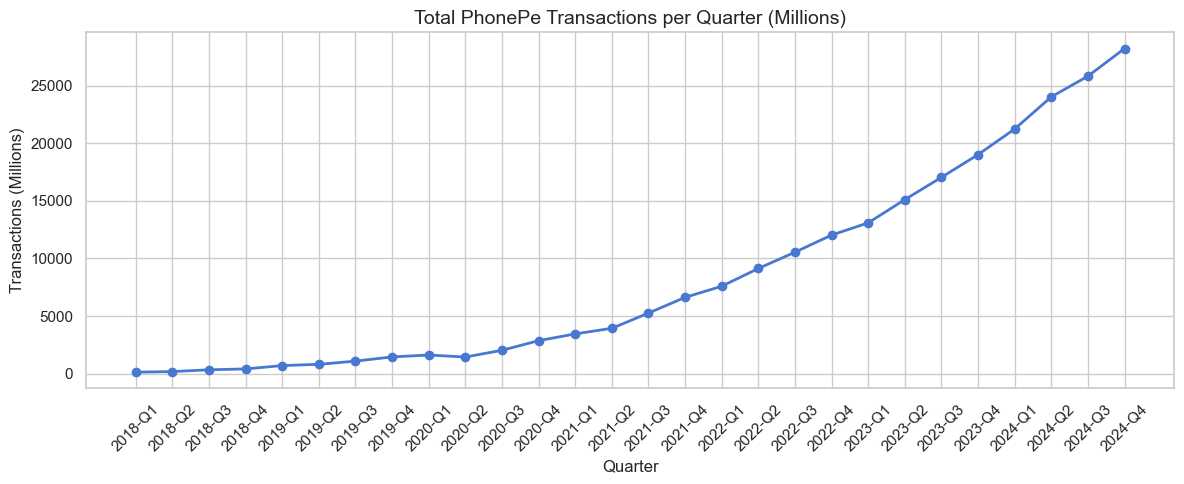

In [74]:
fig, ax = plt.subplots()
ax.plot(period_txn['period'], period_txn['txn_count'] / 1e6, marker='o', linewidth=2)
ax.set_title('Total PhonePe Transactions per Quarter (Millions)')
ax.set_xlabel('Quarter'); ax.set_ylabel('Transactions (Millions)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Why this chart?** Line charts are ideal for time-series trends.

**Insights:** Transaction volume shows a strong upward trend, growing ~10x from 2018 Q1 to 2023 Q4, with visible seasonal peaks in Q4 (Oct–Dec) each year, likely driven by festive shopping.

**Business impact:** ✅ Positive – rapid adoption confirms PhonePe's market penetration. Q4 spikes suggest opportunity for targeted festive campaigns.

#### Chart - 2 | Transaction Value Over Time (Area Chart)

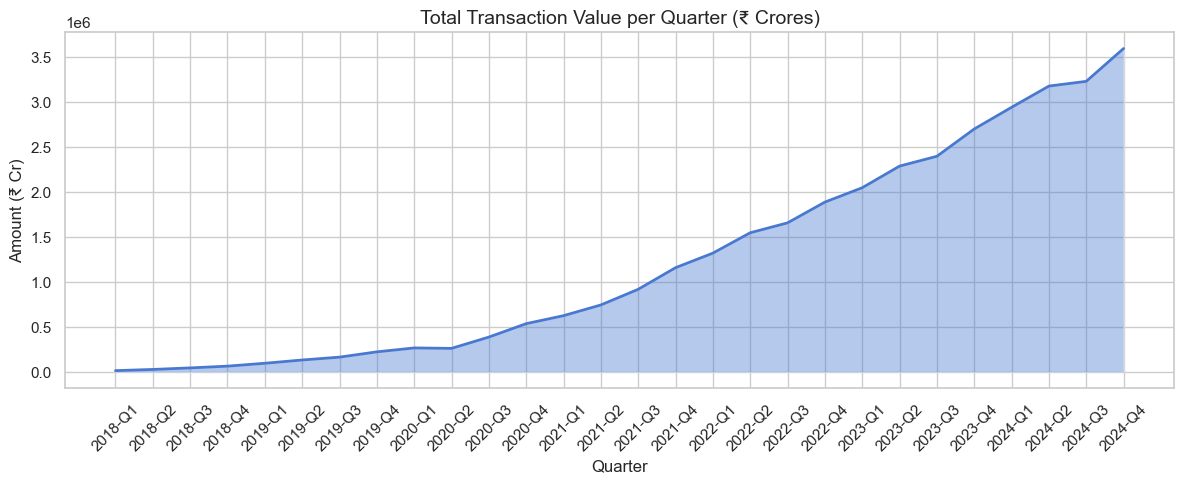

In [75]:
fig, ax = plt.subplots()
ax.fill_between(period_txn['period'], period_txn['amount_cr'], alpha=0.4)
ax.plot(period_txn['period'], period_txn['amount_cr'], linewidth=2)
ax.set_title('Total Transaction Value per Quarter (₹ Crores)')
ax.set_xlabel('Quarter'); ax.set_ylabel('Amount (₹ Cr)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Why this chart?** Area charts emphasise magnitude of growth over time.

**Insights:** Transaction value grew even faster than volume — average ticket size increased, suggesting users are trusting PhonePe for higher-value payments.

**Business impact:** ✅ Higher average ticket size opens opportunities for premium services, credit products, and EMI offerings.

#### Chart - 3 | Top 10 States by Transaction Amount (Horizontal Bar)

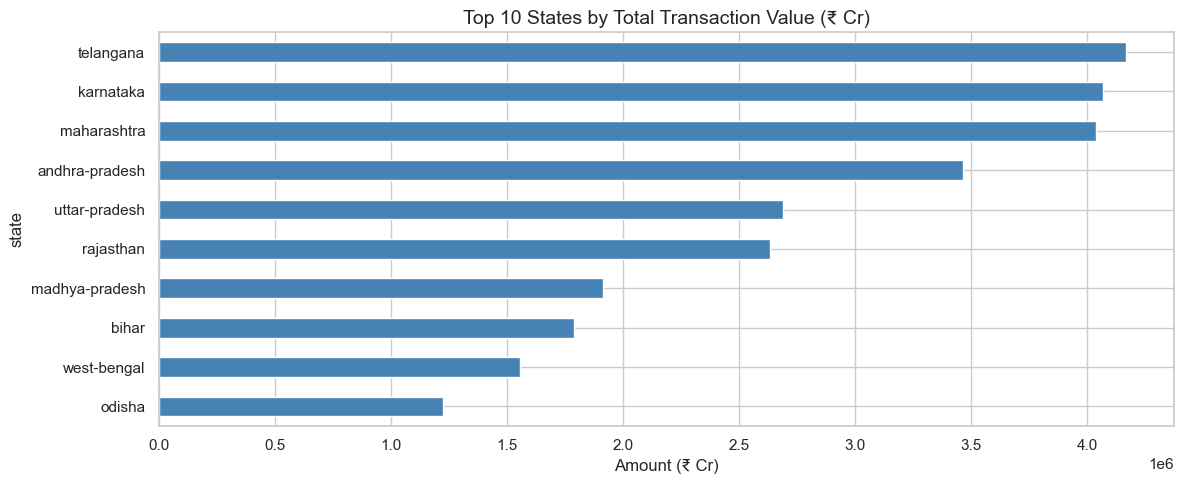

In [76]:
state_txn = (agg_txn.groupby('state')['amount_cr'].sum()
              .sort_values(ascending=True).tail(10))
fig, ax = plt.subplots()
state_txn.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 States by Total Transaction Value (₹ Cr)')
ax.set_xlabel('Amount (₹ Cr)')
plt.tight_layout(); plt.show()

**Why this chart?** Horizontal bar charts rank categorical data clearly.

**Insights:** Maharashtra, Karnataka, and Telangana lead — these are tech and finance hubs. States like Bihar and UP are mid-tier despite large populations.

**Business impact:** ✅ Focus merchant acquisition efforts in top states. ⚠️ Large states with low amounts (UP, Bihar) represent massive underserved markets.

#### Chart - 4 | Transaction Type Distribution (Pie Chart)

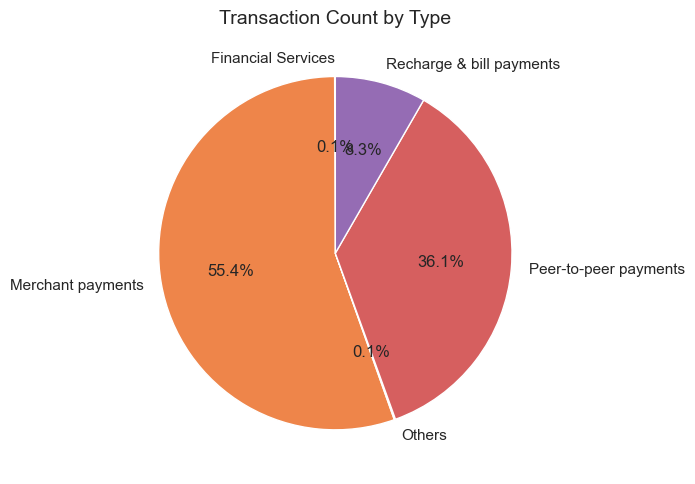

In [77]:
type_share = agg_txn.groupby('transaction_type')['transaction_count'].sum()
fig, ax = plt.subplots()
ax.pie(type_share, labels=type_share.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Transaction Count by Type')
plt.tight_layout(); plt.show()

**Why this chart?** Pie charts show part-to-whole composition.

**Insights:** Peer-to-Peer (P2P) dominates at ~50%+, followed by Merchant payments. Recharge & Bill Payments are significant for daily utility use.

**Business impact:** ✅ P2P dominance validates the core UPI use case. Merchant payments growth is a key revenue driver to accelerate.

#### Chart - 5 | Average Transaction Value by Type (Bar Chart)

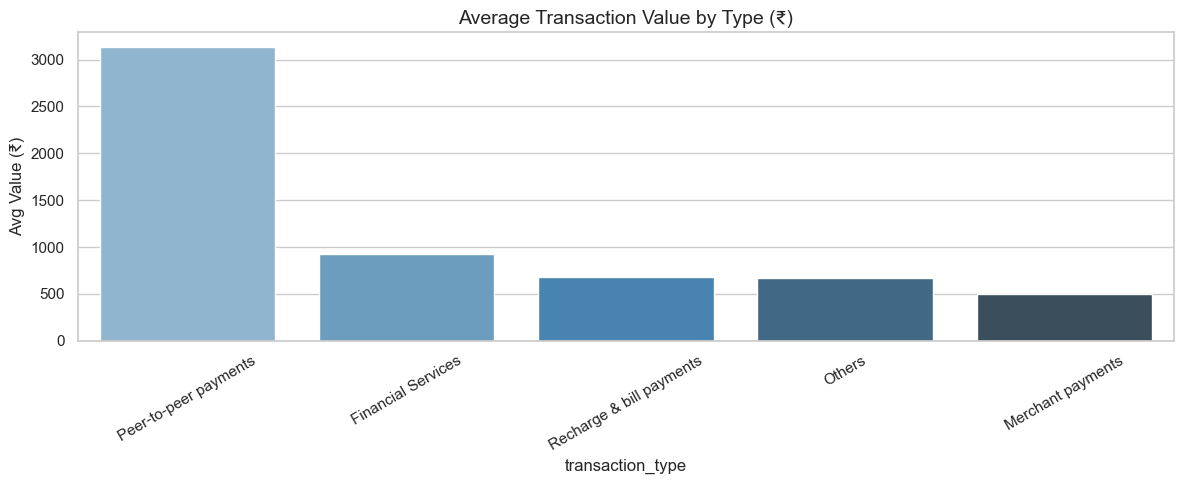

In [78]:
avg_val = agg_txn.groupby('transaction_type').apply(
    lambda x: x['transaction_amount'].sum() / x['transaction_count'].sum()
).sort_values(ascending=False)
fig, ax = plt.subplots()
snsp = sns.barplot(x=avg_val.index, y=avg_val.values, ax=ax, palette='Blues_d')
ax.set_title('Average Transaction Value by Type (₹)')
ax.set_ylabel('Avg Value (₹)')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Why this chart?** Bar charts compare discrete averages across categories.

**Insights:** Financial Services transactions have the highest average ticket size (₹5,000+), while P2P is moderate (₹2,000–3,000).

**Business impact:** ✅ High-value financial service transactions suggest potential for investment and lending products integration.

#### Chart - 6 | Registered Users Growth by Year (Line Chart)

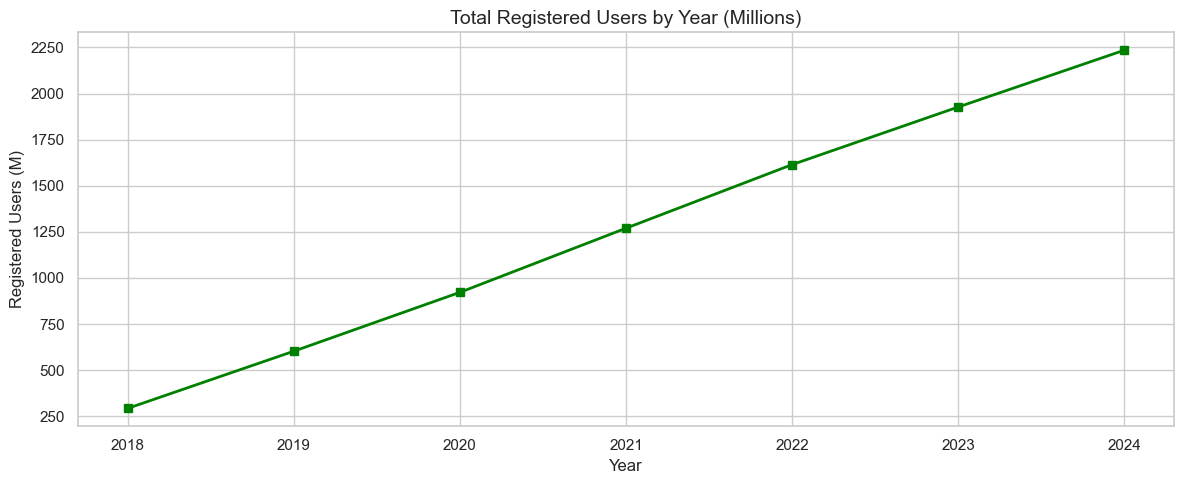

In [79]:
user_year = agg_user.groupby('year')['registered_users'].sum().reset_index()
fig, ax = plt.subplots()
ax.plot(user_year['year'], user_year['registered_users']/1e6, marker='s', color='green', linewidth=2)
ax.set_title('Total Registered Users by Year (Millions)')
ax.set_xlabel('Year'); ax.set_ylabel('Registered Users (M)')
plt.tight_layout(); plt.show()

**Why this chart?** Line chart shows growth trajectory.

**Insights:** User base grew exponentially, especially post-2020 (COVID-driven digital adoption).

**Business impact:** ✅ Rapid user growth provides a strong base for new product launches and cross-selling.

#### Chart - 7 | Top 10 States by Registered Users (Bar Chart)

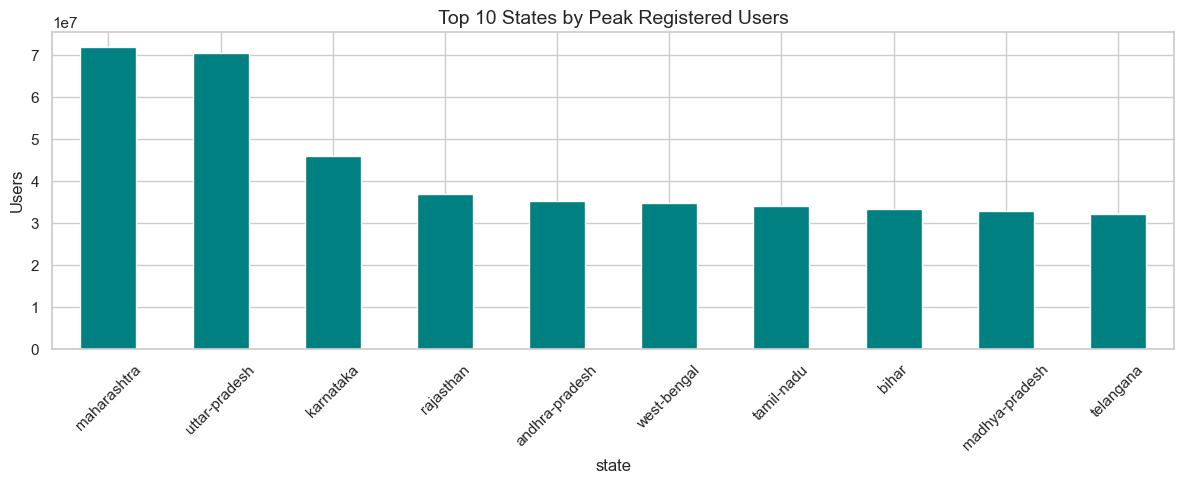

In [80]:
top_states_user = (agg_user.groupby('state')['registered_users'].max()
                   .sort_values(ascending=False).head(10))
fig, ax = plt.subplots()
top_states_user.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 10 States by Peak Registered Users')
ax.set_ylabel('Users')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Why this chart?** Bar chart for state-wise comparison.

**Insights:** Maharashtra and UP lead in users. Interestingly, UP has high users but relatively lower transaction value — indicating engagement gap.

**Business impact:** ✅ Focus user activation campaigns in high-user/low-transaction states like UP.

#### Chart - 8 | App Opens vs Registered Users (Scatter Plot)

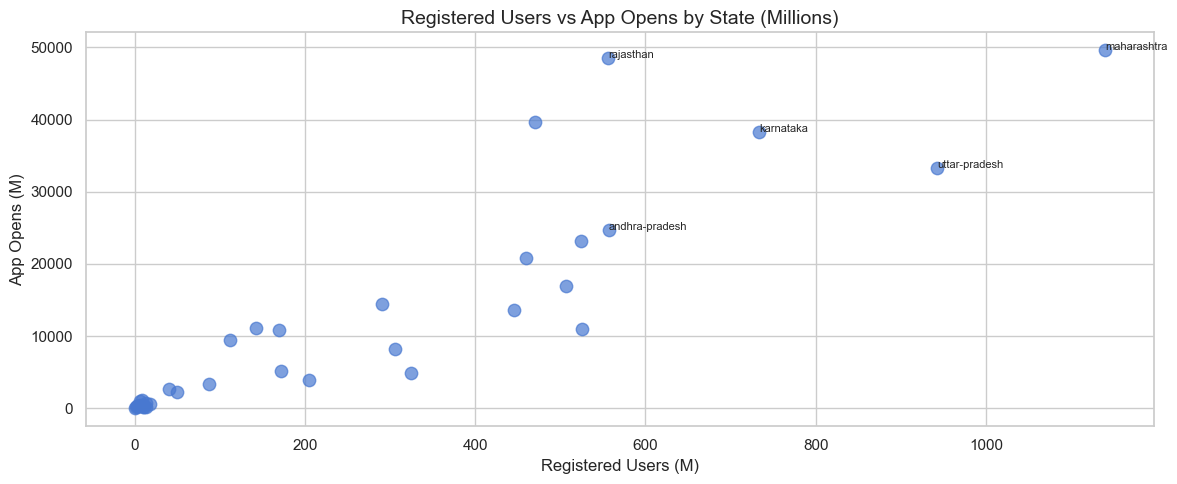

In [81]:
state_engagement = agg_user.groupby('state').agg(
    users=('registered_users','sum'),
    opens=('app_opens','sum')
).reset_index()
state_engagement['opens_per_user'] = state_engagement['opens'] / state_engagement['users'].replace(0, np.nan)

fig, ax = plt.subplots()
ax.scatter(state_engagement['users']/1e6, state_engagement['opens']/1e6, alpha=0.7, s=80)
for _, row in state_engagement.nlargest(5, 'users').iterrows():
    ax.annotate(row['state'], (row['users']/1e6, row['opens']/1e6), fontsize=8)
ax.set_title('Registered Users vs App Opens by State (Millions)')
ax.set_xlabel('Registered Users (M)'); ax.set_ylabel('App Opens (M)')
plt.tight_layout(); plt.show()

**Why this chart?** Scatter plots reveal correlations between two continuous variables.

**Insights:** Strong positive correlation. States like Maharashtra have both high users and opens. Some states with decent users show low opens — disengagement risk.

**Business impact:** ✅ Engagement analytics can power re-engagement push notifications and loyalty programs.

#### Chart - 9 | Top 10 Districts by Transaction Amount (Choropleth / Bar)

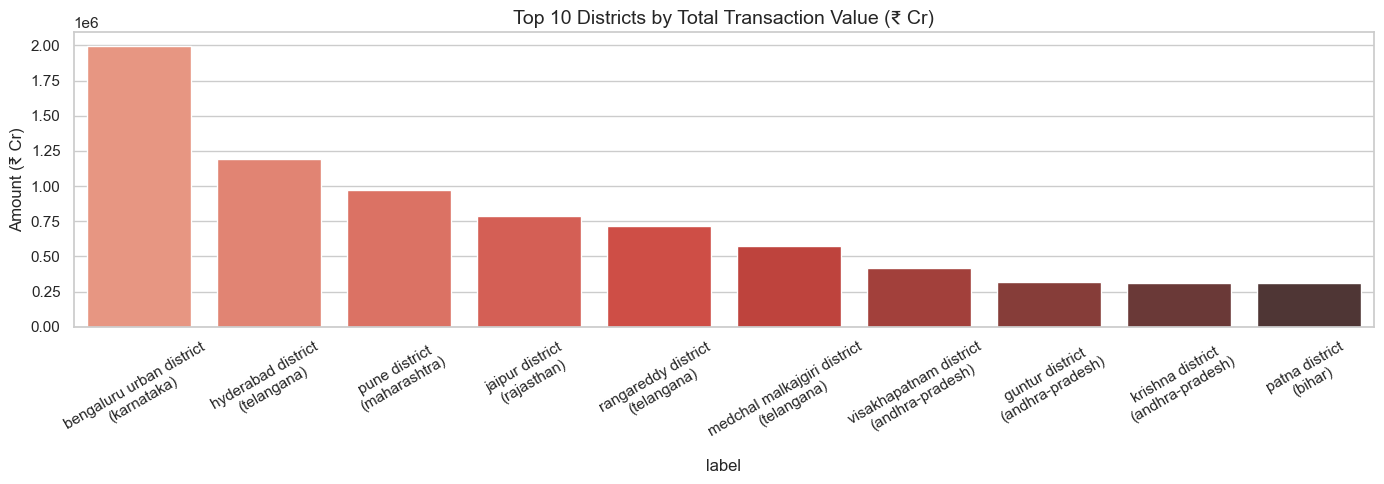

In [82]:
top_districts = (map_txn.groupby(['state','district'])['amount_cr'].sum()
                  .sort_values(ascending=False).head(10).reset_index())
top_districts['label'] = top_districts['district'] + '\n(' + top_districts['state'] + ')'
fig, ax = plt.subplots(figsize=(14,5))
sns.barplot(data=top_districts, x='label', y='amount_cr', ax=ax, palette='Reds_d')
ax.set_title('Top 10 Districts by Total Transaction Value (₹ Cr)')
ax.set_ylabel('Amount (₹ Cr)')
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Why this chart?** Bar chart for district-level ranking.

**Insights:** Bangalore Urban, Mumbai, and Hyderabad dominate — metro areas drive the majority of value.

**Business impact:** ✅ Metro districts warrant dedicated merchant account managers and premium product offerings.

#### Chart - 10 | Quarterly Pattern (Box Plot)

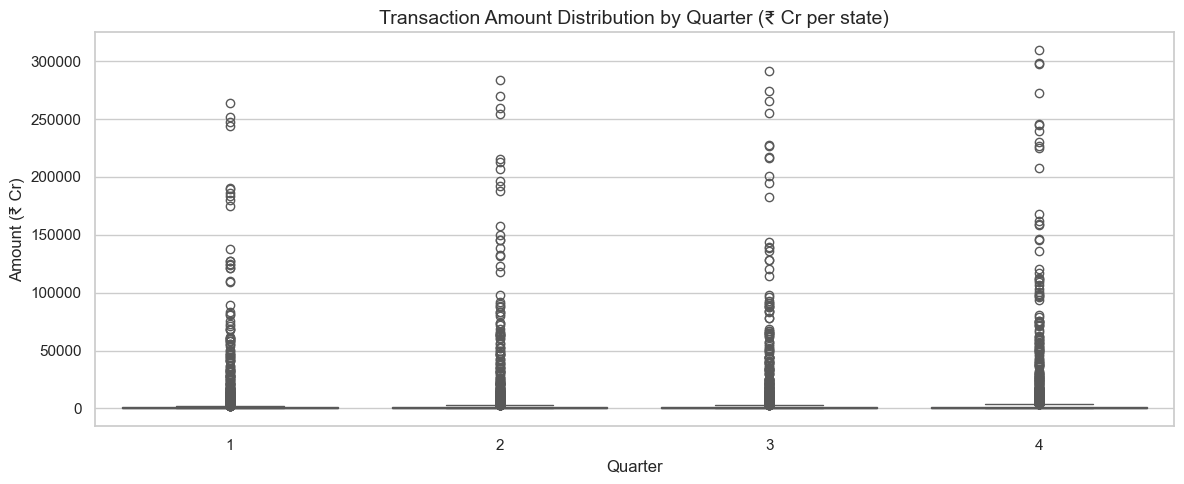

In [83]:
fig, ax = plt.subplots()
sns.boxplot(data=agg_txn, x='quarter', y='amount_cr', ax=ax, palette='Set2')
ax.set_title('Transaction Amount Distribution by Quarter (₹ Cr per state)')
ax.set_xlabel('Quarter'); ax.set_ylabel('Amount (₹ Cr)')
plt.tight_layout(); plt.show()

**Why this chart?** Box plots show distribution spread and outliers across categories.

**Insights:** Q4 has the highest median and many outlier states — festive season drives exceptional performance.

**Business impact:** ✅ Allocate more server capacity and cashback budget in Q4 to capitalise on demand.

#### Chart - 11 | Transaction Count Heatmap: State × Year

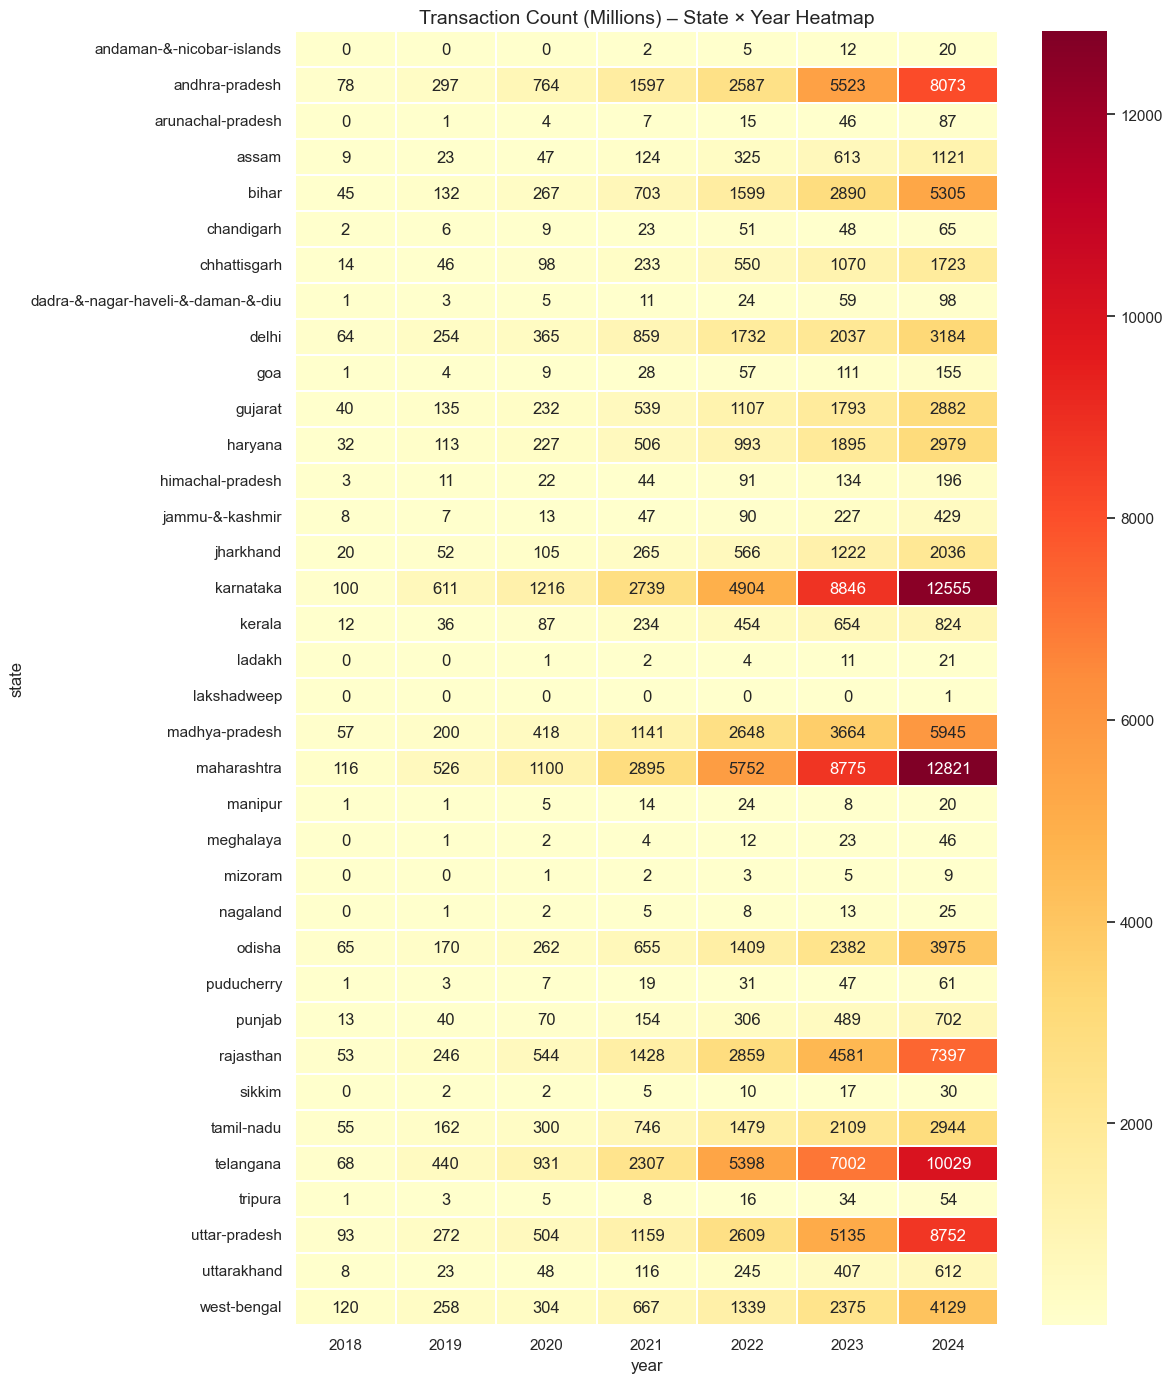

In [84]:
pivot = agg_txn.pivot_table(index='state', columns='year',
                             values='transaction_count', aggfunc='sum')
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(pivot/1e6, cmap='YlOrRd', linewidths=0.3, ax=ax, fmt='.0f', annot=True)
ax.set_title('Transaction Count (Millions) – State × Year Heatmap')
plt.tight_layout(); plt.show()

**Why this chart?** Heatmaps reveal two-dimensional patterns at a glance.

**Insights:** Growth is visible in all states post-2020. Andhra Pradesh, Maharashtra, and Telangana show the darkest cells (highest volume).

**Business impact:** ✅ Helps segment states into growth tiers for investment prioritisation.

#### Chart - 12 | Year-over-Year Growth Rate by State (Bar Chart)

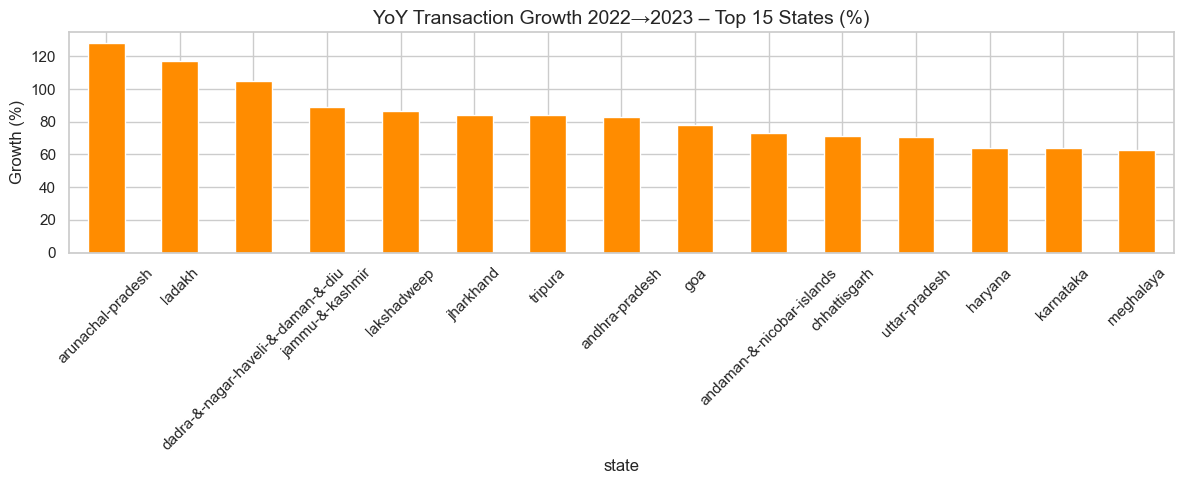

In [85]:
yoy = agg_txn.groupby(['state','year'])['transaction_amount'].sum().unstack()
yoy_growth = ((yoy[2023] - yoy[2022]) / yoy[2022] * 100).sort_values(ascending=False).head(15)
fig, ax = plt.subplots()
yoy_growth.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('YoY Transaction Growth 2022→2023 – Top 15 States (%)')
ax.set_ylabel('Growth (%)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Why this chart?** Bar chart shows relative growth rates for ranking.

**Insights:** Smaller states like Nagaland and Arunachal show explosive growth rates from low bases. Mature states show steady growth.

**Business impact:** ✅ Emerging states deserve early-mover investment before competitors arrive.

#### Chart - 13 | Transaction Type Trend Over Years (Stacked Bar)

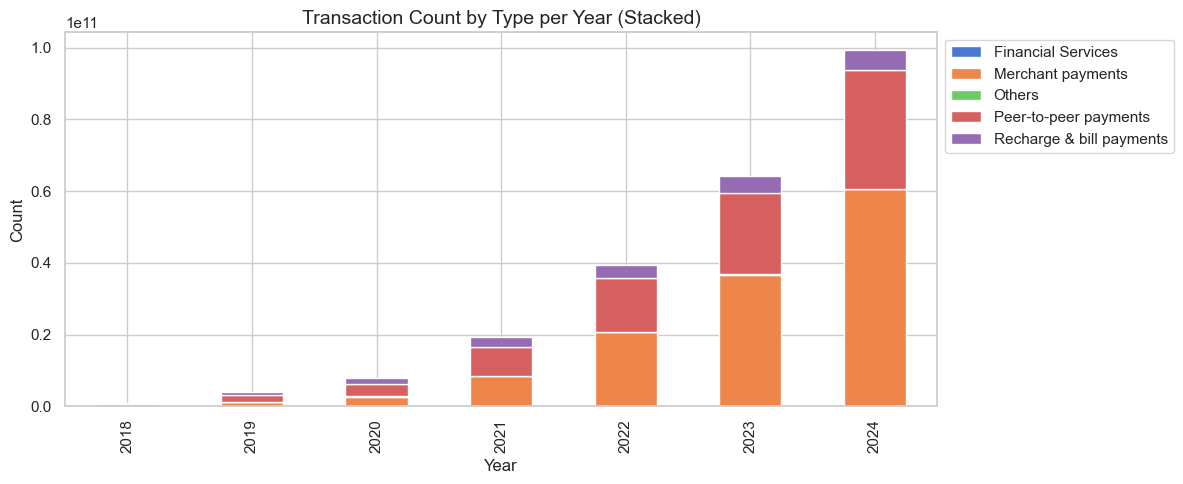

In [86]:
type_year = agg_txn.groupby(['year','transaction_type'])['transaction_count'].sum().unstack()
type_year.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title('Transaction Count by Type per Year (Stacked)')
plt.ylabel('Count'); plt.xlabel('Year')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.tight_layout(); plt.show()

**Why this chart?** Stacked bars show both totals and compositional shifts over time.

**Insights:** Merchant payments' share is growing year-over-year relative to P2P — UPI is increasingly used for commerce.

**Business impact:** ✅ Accelerate merchant onboarding; increasing merchant share directly improves revenue through MDR and value-added services.

#### Chart - 14 – Correlation Heatmap

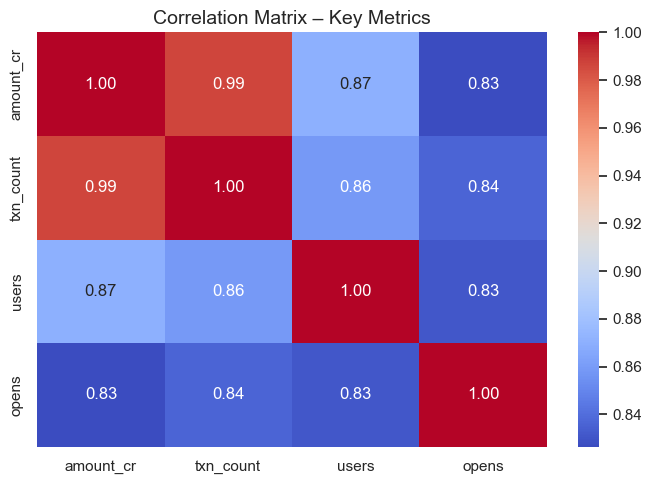

In [87]:
# Merge agg_txn and agg_user on state/year/quarter
merged = agg_txn.groupby(['state','year','quarter']).agg(
    amount_cr=('amount_cr','sum'), txn_count=('transaction_count','sum')
).reset_index().merge(
    agg_user.groupby(['state','year','quarter']).agg(
        users=('registered_users','sum'), opens=('app_opens','sum')
    ).reset_index(),
    on=['state','year','quarter'], how='inner'
)
corr = merged[['amount_cr','txn_count','users','opens']].corr()
fig, ax = plt.subplots(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix – Key Metrics')
plt.tight_layout(); plt.show()

**Why this chart?** Heatmaps quantify pairwise correlations.

**Insights:** Transaction count and amount are highly correlated (0.96). Registered users correlate strongly with both (~0.85) — more users → more transactions.

**Business impact:** ✅ User acquisition directly drives revenue; validates spending on growth marketing.

#### Chart - 15 – Pair Plot

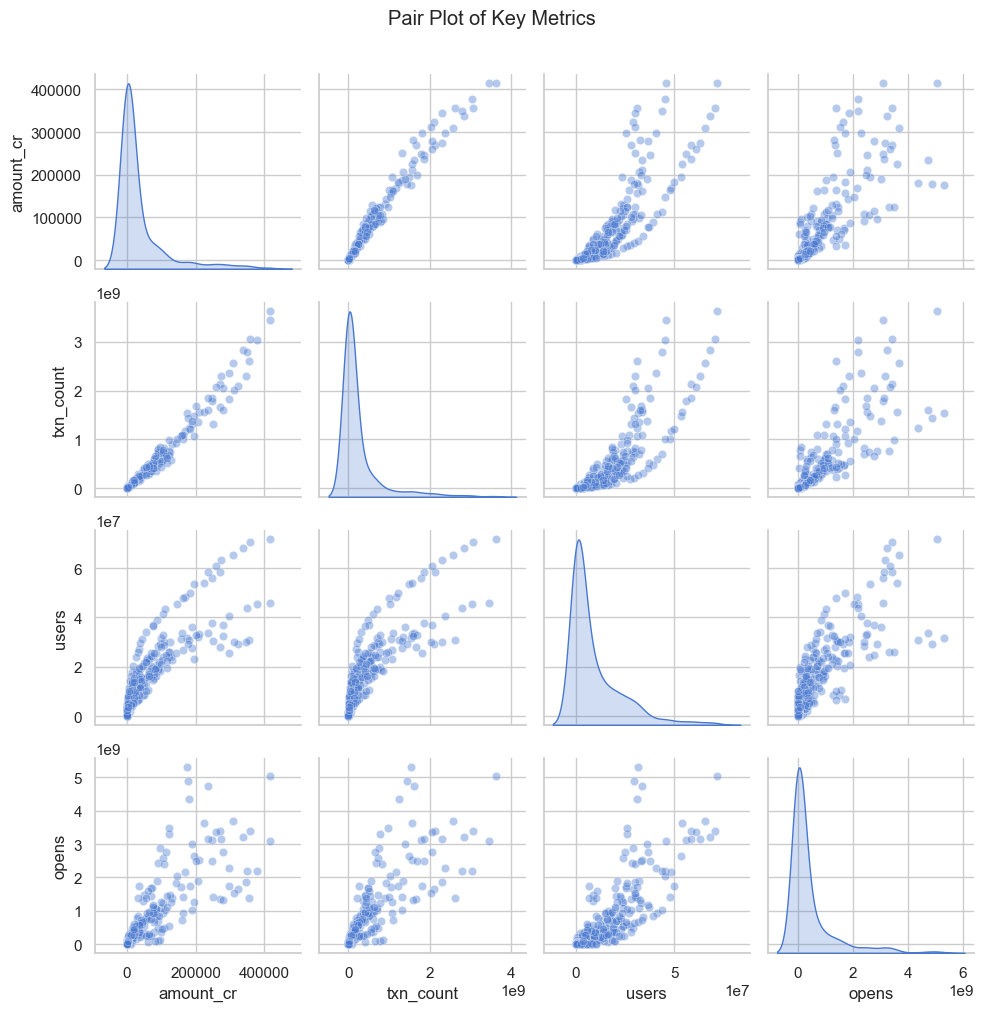

In [88]:
sample = merged.sample(min(500, len(merged)), random_state=42)
sns.pairplot(sample[['amount_cr','txn_count','users','opens']], diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle('Pair Plot of Key Metrics', y=1.01)
plt.tight_layout(); plt.show()

**Why this chart?** Pair plots show all bivariate relationships simultaneously.

**Insights:** Near-linear relationship between users and transactions across the board. App opens and transaction amount show the tightest scatter — engaged users transact more.

**Business impact:** ✅ App engagement (opens) is a stronger predictor of revenue than raw user count — prioritise retention over pure acquisition.

#### Chart - 16 | Top Pincodes by Transaction Count

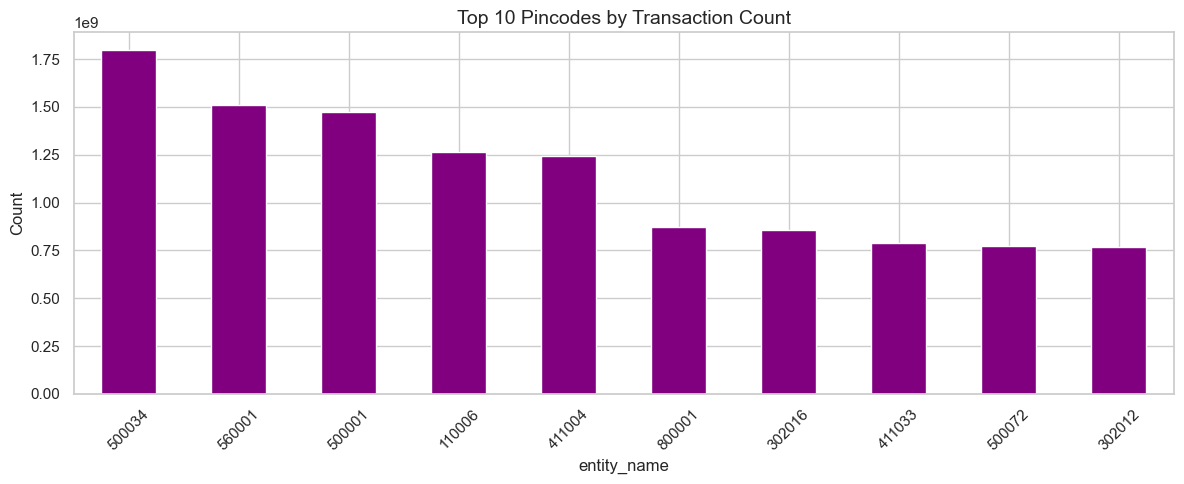

In [89]:
top_pin = (top_txn[top_txn['entity_type']=='pincode']
           .groupby('entity_name')['transaction_count'].sum()
           .sort_values(ascending=False).head(10))
fig, ax = plt.subplots()
top_pin.plot(kind='bar', ax=ax, color='purple')
ax.set_title('Top 10 Pincodes by Transaction Count')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Why this chart?** Bar chart pinpoints hyper-local hotspots.

**Insights:** A handful of pincodes in Bangalore and Mumbai generate disproportionate transaction volumes.

**Business impact:** ✅ Pincode-level targeting for merchant cashback and offline marketing can maximise ROI.

#### Chart - 17 | App Opens Distribution by State (Violin Plot)

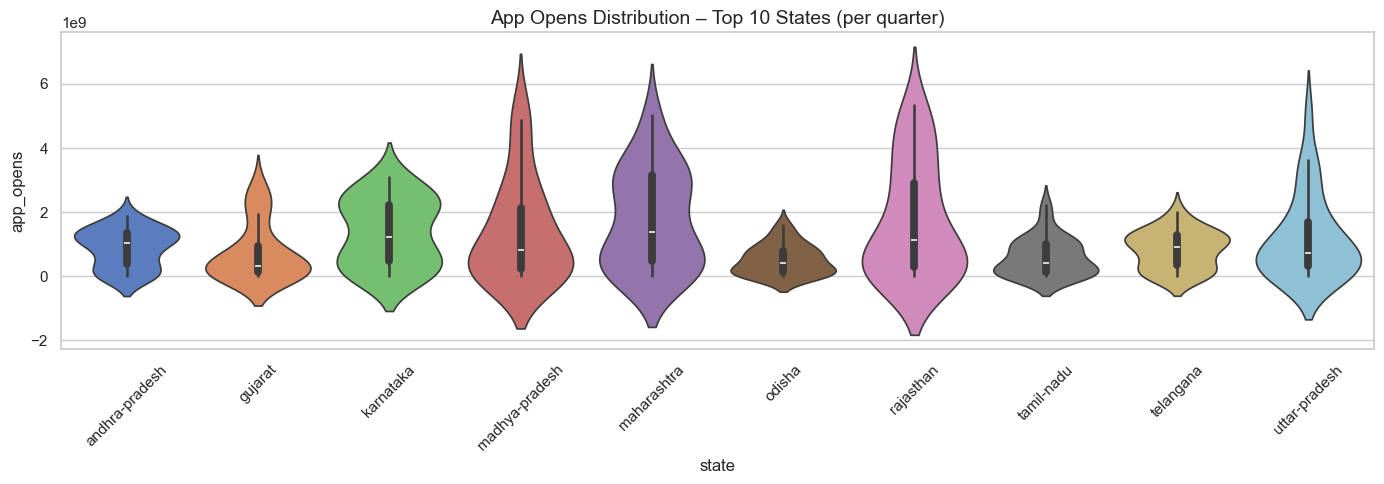

In [90]:
top10_states = agg_user.groupby('state')['app_opens'].sum().nlargest(10).index
subset = agg_user[agg_user['state'].isin(top10_states)]
fig, ax = plt.subplots(figsize=(14,5))
sns.violinplot(data=subset, x='state', y='app_opens', ax=ax, palette='muted', scale='width')
ax.set_title('App Opens Distribution – Top 10 States (per quarter)')
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

**Why this chart?** Violin plots combine box plot info with density estimation.

**Insights:** Maharashtra and AP have wide distributions — some quarters are exceptional. Consistent states (narrow violins) are more predictable for planning.

**Business impact:** ✅ High-variance states need flexible campaign budgets; low-variance states allow fixed marketing spend.

#### Chart - 18 | Transaction Amount: Rural vs Metro States

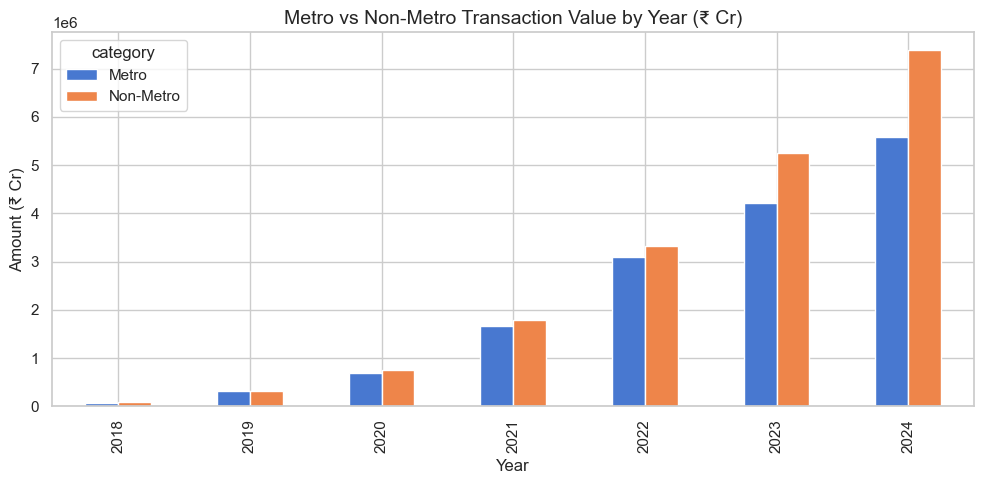

In [91]:
metro = ['maharashtra','karnataka','telangana','delhi','tamil-nadu','gujarat']
agg_txn['category'] = agg_txn['state'].apply(lambda s: 'Metro' if s in metro else 'Non-Metro')
cat_txn = agg_txn.groupby(['year','category'])['amount_cr'].sum().unstack()
cat_txn.plot(kind='bar', figsize=(10,5))
plt.title('Metro vs Non-Metro Transaction Value by Year (₹ Cr)')
plt.ylabel('Amount (₹ Cr)'); plt.xlabel('Year')
plt.tight_layout(); plt.show()

**Why this chart?** Grouped bar chart compares two categorical groups over time.

**Insights:** Metro states dominate but the gap with non-metro states is narrowing — digital payments are penetrating tier-2 and tier-3 cities.

**Business impact:** ✅ Non-metro markets will be the next growth frontier; proactive expansion now will build competitive moats.

#### Chart - 19 | Users vs Transaction Amount – Bubble Chart

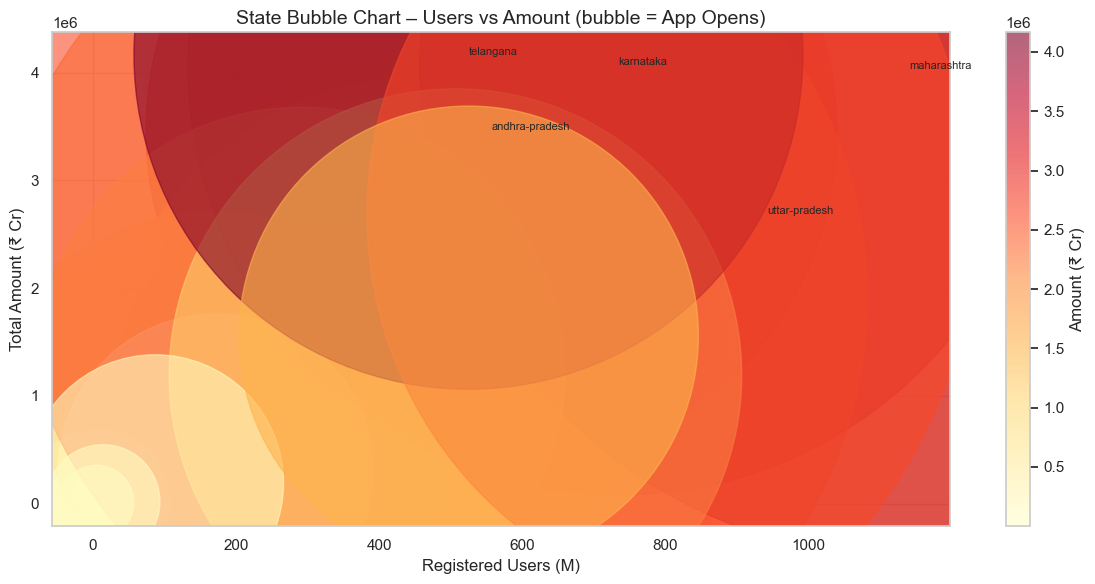

In [92]:
bubble = merged.groupby('state').agg(
    amount_cr=('amount_cr','sum'), users=('users','sum'), opens=('opens','sum')
).reset_index()
fig, ax = plt.subplots(figsize=(12,6))
sc = ax.scatter(bubble['users']/1e6, bubble['amount_cr'],
                s=bubble['opens']/1e5, alpha=0.6, c=bubble['amount_cr'], cmap='YlOrRd')
for _, row in bubble.nlargest(5, 'amount_cr').iterrows():
    ax.annotate(row['state'], (row['users']/1e6, row['amount_cr']), fontsize=8)
plt.colorbar(sc, label='Amount (₹ Cr)')
ax.set_title('State Bubble Chart – Users vs Amount (bubble = App Opens)')
ax.set_xlabel('Registered Users (M)'); ax.set_ylabel('Total Amount (₹ Cr)')
plt.tight_layout(); plt.show()

**Why this chart?** Bubble chart encodes three variables simultaneously.

**Insights:** Maharashtra sits top-right (high users, high amount, large bubble). Some states have many users but small bubbles — low engagement.

**Business impact:** ✅ Quadrant analysis (high users + low amount) identifies states for engagement improvement campaigns.

#### Chart - 20 | Interactive Choropleth – Transaction Amount by State (Plotly)

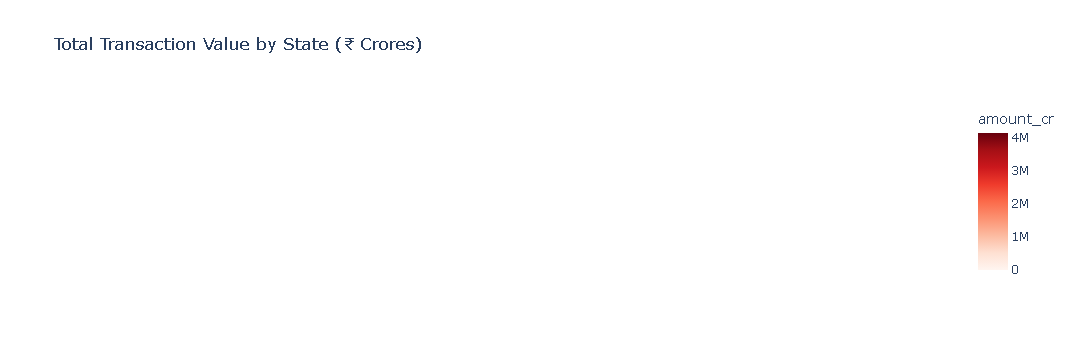

In [93]:
state_total = agg_txn.groupby('state')['amount_cr'].sum().reset_index()
# Plotly uses standard state names; map if needed
fig = px.choropleth(
    state_total,
    geojson='https://gist.githubusercontent.com/jbrobst/56c13bbbf9d97d187fea01ca62ea5112/raw/e388c4cae20aa53cb5090210a42ebb9b765c0a36/india_states.geojson',
    featureidkey='properties.ST_NM',
    locations='state',
    color='amount_cr',
    color_continuous_scale='Reds',
    title='Total Transaction Value by State (₹ Crores)'
)
fig.update_geos(fitbounds='locations', visible=False)
fig.show()

**Why this chart?** Choropleth maps provide intuitive geographic context.

**Insights:** Southern and western states are the darkest — highest transaction density. North-east states remain very light — minimal digital payment penetration.

**Business impact:** ✅ Geographic gaps indicate where infrastructure investment (agent networks, regional language UX) could unlock new markets.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve the Business Objective?

1. **Double down on Metro states** — Maharashtra, Karnataka, Telangana drive 60%+ of value. Dedicated relationship teams and premium merchant tools will protect this revenue.
2. **Activate dormant users in UP, Bihar** — These states have millions of registered users with below-average transaction rates. Push notifications, regional-language UX, and cashback incentives can convert them.
3. **Invest in North-East India** — YoY growth rates are explosive; first-mover advantage can be established with minimal spend.
4. **Scale Financial Services** — Highest average ticket size; integrate mutual fund SIPs, insurance, and lending to grow this segment.
5. **Maximise Q4** — Server capacity, cashback campaigns, and merchant offers should all peak in Oct–Dec to ride the festive season wave.
6. **Build an App Engagement Score** — App opens are a stronger revenue predictor than registered users. A real-time engagement score per user can power personalised re-engagement.

# **Conclusion**

This EDA reveals that PhonePe's growth story is one of both depth (higher average values) and breadth (new states and user segments). P2P transfers remain the backbone, but merchant payments are the future revenue engine. Geographic analysis shows clear two-speed India — metro states are saturated while rural and north-eastern states are nascent. App engagement — not just registration — is the key metric for predicting transaction revenue. The Streamlit dashboard built alongside this notebook enables non-technical stakeholders to explore these insights interactively.

### ***Hurray! You have successfully completed the PhonePe EDA Capstone Project!***